# Figure 2 and appendix figures: well-specified simulation (R1)

Reads the per-replication rows written by

```bash
python experiments/simulation/r1_main.py --config main10     --row both --seeds 0:50 --workers 6
python experiments/simulation/r1_main.py --config app20      --row both --seeds 0:50 --workers 6
python experiments/simulation/r1_main.py --config main10_mis --row both --seeds 0:50 --workers 6
```

and renders the two-row main figure (`figures/r1_main10.pdf`), the $N=20$ replicate (`r1_app20.pdf`), and the misaligned-target appendix figure (`r1_main10_mis.pdf`) with the unified method panel of `experiments/style.py`.
The human target is $s_0=\alpha_0\mu$ in `main10` and `app20` (aligned with the consensus, $c_V=0$) and $s_0=Wc_0$ with $c_V\sim N(0,0.5^2)$ in `main10_mis`.

In [1]:
import sys
from pathlib import Path
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np, pandas as pd

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.simulation.r1_plot import COLS, aggregate, load  # noqa: E402
from experiments.style import PRESENTED, LABEL, STYLE, INK_SOFT, GRID, plot_kwargs  # noqa: E402
FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)

PANELS = [  # (column in rows.jsonl, panel title, log y)
    ("excess", "excess human risk", True),
    ("kendall", r"Kendall $\tau(\hat s, s_0)$", False),
    ("cov_s", "95% CI coverage", False),
    ("b_rmse", r"RMSE$(\hat b, b)$", True),
]

## Load and aggregate

`load` marks a replication irregular when the staged endpoint (Consensus-cal) or the fixed-weight joint fit is flagged as non-convergent (separation in a judge-item cell at the smallest LLM budgets); `aggregate` averages over the regular replications and counts the excluded ones.

In [2]:
frames = {}
for cfg in ("main10", "app20", "main10_mis"):
    path = REPO / "results" / "r1" / cfg / "rows.jsonl"
    if not path.exists():
        print(f"{cfg}: no rows at {path}; run r1_main.py first"); continue
    df = load(cfg, base=REPO); agg = aggregate(df); frames[cfg] = (df, agg)
    n_irr = int(df[df.irregular][["row", "n_L", "n_0", "seed"]].drop_duplicates().shape[0])
    print(f"{cfg}: N={int(df.N.iloc[0])}, K={int(df.K.iloc[0])}, r={int(df.r.iloc[0])}, c_v_sd={df.c_v_sd.iloc[0]}, seeds={df.seed.nunique()}, "
          f"cells={df[['row','n_L','n_0']].drop_duplicates().shape[0]}, irregular replications excluded={n_irr}, failed rows={int(df.get('error', pd.Series(dtype=object)).notna().sum()) if 'error' in df else 0}")

/Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/experiments/simulation/r1_plot.py:50: RuntimeWarning: All-NaN slice encountered
  lam_med=("lam", lambda x: np.nanmedian(x.replace(np.inf, np.nan))) if "lam" in reg else ("seed", "size"),
/Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/experiments/simulation/r1_plot.py:50: RuntimeWarning: All-NaN slice encountered
  lam_med=("lam", lambda x: np.nanmedian(x.replace(np.inf, np.nan))) if "lam" in reg else ("seed", "size"),


main10: N=10, K=4, r=1, c_v_sd=0.0, seeds=50, cells=11, irregular replications excluded=3, failed rows=0
app20: N=20, K=6, r=2, c_v_sd=0.0, seeds=50, cells=11, irregular replications excluded=0, failed rows=0


main10_mis: N=10, K=4, r=1, c_v_sd=0.5, seeds=50, cells=11, irregular replications excluded=3, failed rows=0


/Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/experiments/simulation/r1_plot.py:50: RuntimeWarning: All-NaN slice encountered
  lam_med=("lam", lambda x: np.nanmedian(x.replace(np.inf, np.nan))) if "lam" in reg else ("seed", "size"),


## Figure

Drawn at the ICLR text-block width (5.5 in) so fonts are true size. Theory lines in the top-left panel: $(N-1)/(2n_0)$ for human-only BTL and $1/(2n_0)$ for calibration of the single coefficient $\alpha$ within $\operatorname{span}(\mu)$ (Theorem `thm:population-risk-tradeoff` with $d=1$); for the misaligned target the anchored line is $(r+1)/(2n_0)$ for DIAL-W.

saved /Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/figures/r1_main10.pdf (50 seeds)


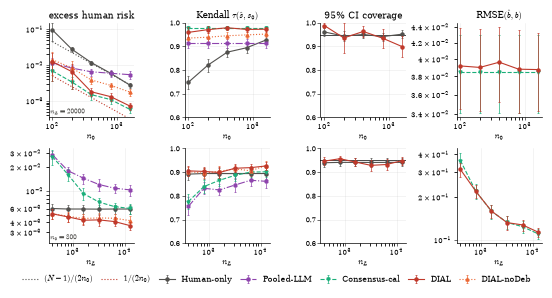

saved /Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/figures/r1_app20.pdf (50 seeds)


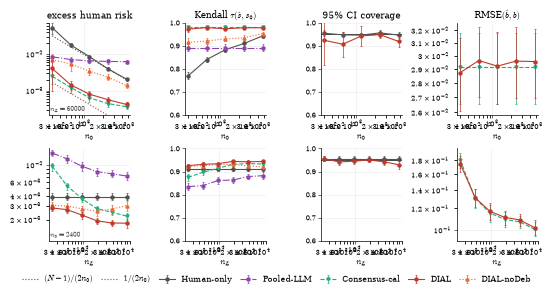

In [3]:
def draw(agg, N, r, out, seeds, methods, theory_dims, extra=()):
    mpl.rcParams.update({"font.size": 6, "axes.titlesize": 6.2, "axes.labelsize": 6, "xtick.labelsize": 5.2, "ytick.labelsize": 5.2, "legend.fontsize": 5.8,
                         "axes.linewidth": 0.5, "xtick.major.width": 0.4, "ytick.major.width": 0.4, "xtick.major.size": 2, "ytick.major.size": 2, "mathtext.fontset": "cm",
                         "font.family": "serif"})
    fig, axes = plt.subplots(2, len(PANELS), figsize=(5.5, 2.75))
    ms, lw, cs, elw = 2.2, 0.8, 1.0, 0.5
    for ri, (row, xcol, xlabel) in enumerate([("n0", "n_0", "$n_0$"), ("nL", "n_L", "$n_L$")]):
        d = agg[agg.row == row]
        for ci, (col, title, logy) in enumerate(PANELS):
            ax = axes[ri, ci]
            if col == "excess" and row == "n0":
                x = np.array(sorted(d.n_0.unique()), float)
                for dim, lab, color in theory_dims:
                    ax.plot(x, dim / (2 * x), ":", color=color, lw=lw, label=lab)
            for m in list(methods) + list(extra):
                s_ = d[d.method == m].sort_values(xcol)
                if s_.empty: continue
                y = s_[f"{col}_mean"].values
                if np.all(np.isnan(y)): continue
                st = plot_kwargs(m); mk = st.pop("marker", None); st.pop("lw", None)
                ax.errorbar(s_[xcol], y, yerr=1.96 * s_[f"{col}_se"].values, marker=mk, ms=ms, lw=lw, elinewidth=elw, capsize=cs, capthick=elw,
                            label=LABEL[m], zorder=3 if m == "dial_mu" else 2, **st)
            if col == "cov_s": ax.axhline(0.95, color="k", lw=0.5, zorder=1); ax.set_ylim(0.6, 1.0)
            if col == "kendall": ax.set_ylim(min(0.6, ax.get_ylim()[0]), 1.0)
            if col == "excess":
                lo = np.nanmin(d[d.method.isin(methods)][f"{col}_mean"].values); ax.set_ylim(lo * 0.6, ax.get_ylim()[1])
            ax.set_xscale("log")
            if logy: ax.set_yscale("log")
            ax.set_xlabel(xlabel, labelpad=1)
            if ri == 0: ax.set_title(title, pad=3)
            ax.grid(alpha=0.25, which="major", lw=0.4); ax.tick_params(pad=1.5)
            for sp in ("top", "right"): ax.spines[sp].set_visible(False)
        fixed = f"$n_L={int(d.n_L.iloc[0])}$" if row == "n0" else f"$n_0={int(d.n_0.iloc[0])}$"
        axes[ri, 0].annotate(fixed, xy=(0.02, 0.04), xycoords="axes fraction", fontsize=5.2, color=INK_SOFT)
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=min(len(l), 8), frameon=False, bbox_to_anchor=(0.5, -0.06), handlelength=2.0, columnspacing=1.0)
    fig.tight_layout(w_pad=0.6, h_pad=0.6)
    fig.savefig(out, bbox_inches="tight"); fig.savefig(out.with_suffix(".png"), dpi=200, bbox_inches="tight")
    print("saved", out, f"({seeds} seeds)")
    return fig

for cfg in ("main10", "app20"):
    if cfg not in frames: continue
    df, agg = frames[cfg]; N, r = int(df.N.iloc[0]), int(df.r.iloc[0])
    theory = [(N - 1, "$(N-1)/(2n_0)$", STYLE["human_only"]["color"]), (1, "$1/(2n_0)$", STYLE["dial_mu"]["color"])]
    fig = draw(agg, N, r, FIGURES / f"r1_{cfg}.pdf", df.seed.nunique(), PRESENTED, theory); plt.show()

## Appendix: misaligned human target

`main10_mis` keeps $c_V\ne0$, so the human target has a component in $\operatorname{col}(V)$ that only the $W$-calibration can recover: DIAL (aligned to $\mu$) and Consensus-cal plateau at $\Delta_\mu$, DIAL-W reaches the $(r+1)/(2n_0)$ line. This is the regime the three benchmarks do not exhibit.

saved /Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/figures/r1_main10_mis.pdf (50 seeds)


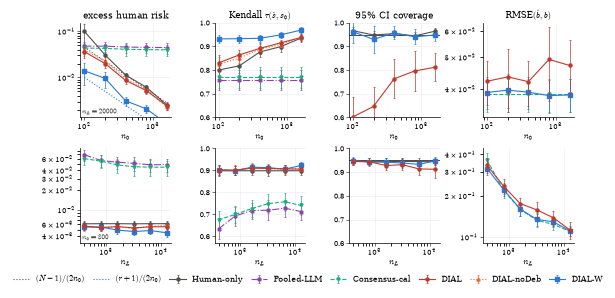

In [4]:
if "main10_mis" in frames:
    df, agg = frames["main10_mis"]; N, r = int(df.N.iloc[0]), int(df.r.iloc[0])
    theory = [(N - 1, "$(N-1)/(2n_0)$", STYLE["human_only"]["color"]), (r + 1, "$(r+1)/(2n_0)$", STYLE["dial_w"]["color"])]
    fig = draw(agg, N, r, FIGURES / "r1_main10_mis.pdf", df.seed.nunique(), PRESENTED, theory, extra=["dial_w"]); plt.show()

## Appendix: GACV diagnostics

Fixed-weight joint fits and the population-risk oracle on DIAL's path, next to DIAL; and the selected relative weight $\widehat\lambda n_0/n_L$.

saved /Users/dujinhong/Library/CloudStorage/Dropbox/应用/Overleaf/Debiasing LLM-as-judge/code/DIAL/figures/r1_main10_diag.pdf (50 seeds)


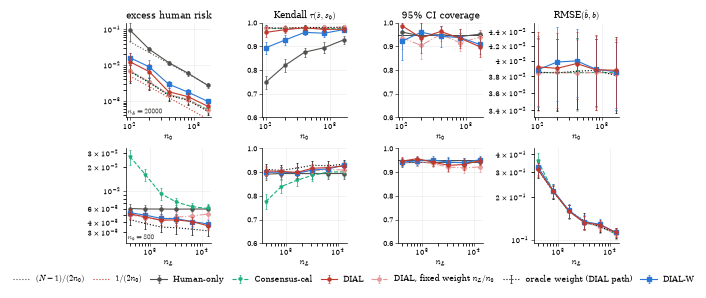

row   n_L  n_0        method  n  excess_mean  kendall_mean  cov_s_mean  cov_s_iid_mean  b_rmse_mean  lam_med  lam_zero_frac  lam_inf_frac  n_irregular
 n0 20000  100 consensus_cal 50       0.0069        0.9778         NaN             NaN       0.0385      NaN          0.000        1.0000          0.0
 n0 20000  100   dial_mle_mu 50       0.0070        0.9778      0.9369          0.9400       0.0384 200.0000          0.000        0.0000          0.0
 n0 20000  100       dial_mu 50       0.0125        0.9591      0.9878          0.9878       0.0392  20.0000          0.040        0.5600          0.0
 n0 20000  100        dial_w 50       0.0161        0.8942      0.9216          0.9205       0.0388  20.0000          0.020        0.6000          0.0
 n0 20000  100    human_only 50       0.0961        0.7484      0.9609             NaN          NaN   0.0000          1.000        0.0000          0.0
 n0 20000  100     oracle_mu 50       0.0066        0.9787         NaN             NaN       0

In [5]:
if "main10" in frames:
    df, agg = frames["main10"]; N, r = int(df.N.iloc[0]), int(df.r.iloc[0])
    theory = [(N - 1, "$(N-1)/(2n_0)$", STYLE["human_only"]["color"]), (1, "$1/(2n_0)$", STYLE["dial_mu"]["color"])]
    fig = draw(agg, N, r, FIGURES / "r1_main10_diag.pdf", df.seed.nunique(), ["human_only", "consensus_cal", "dial_mu"], theory, extra=["dial_mle_mu", "oracle_mu", "dial_w"]); plt.show()
    pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
    show = ["row", "n_L", "n_0", "method", "n", "excess_mean", "kendall_mean", "cov_s_mean", "cov_s_iid_mean", "b_rmse_mean", "lam_med", "lam_zero_frac", "lam_inf_frac", "n_irregular"]
    print(agg[agg.method.isin(["human_only", "consensus_cal", "dial_mu", "dial_mle_mu", "oracle_mu", "dial_w"])][show].round(4).to_string(index=False))

## Numbers quoted in the paper

In [6]:
for cfg, (df, agg) in frames.items():
    print(f"== {cfg}")
    show = ["row", "n_L", "n_0", "method", "n", "excess_mean", "excess_se", "kendall_mean", "cov_s_mean", "b_rmse_mean", "lam_med", "lam_zero_frac", "lam_inf_frac", "n_irregular"]
    print(agg[agg.method.isin(PRESENTED)][show].round(4).to_string(index=False))
if "main10" in frames:
    df, _ = frames["main10"]
    d = df[(df.row == "n0") & (df.method.isin(["dial_mu", "dial_mle_mu", "consensus_cal"])) & (~df.irregular)]
    print("\nmean vs median excess, top row:"); print(d.groupby(["n_0", "method"]).excess.agg(mean="mean", median="median", q90=lambda x: x.quantile(0.9)).round(4))
    sel0 = df[(df.method == "dial_mu") & (df.lam == 0)][["row", "n_L", "n_0", "seed", "excess"]]
    print(f"\nreplications with lambda_hat = 0: {len(sel0)}")

== main10
row   n_L  n_0        method  n  excess_mean  excess_se  kendall_mean  cov_s_mean  b_rmse_mean  lam_med  lam_zero_frac  lam_inf_frac  n_irregular
 n0 20000  100 consensus_cal 50       0.0069     0.0017        0.9778         NaN       0.0385      NaN         0.0000        1.0000          0.0
 n0 20000  100       dial_mu 50       0.0125     0.0045        0.9591      0.9878       0.0392  20.0000         0.0400        0.5600          0.0
 n0 20000  100    dial_nodeb 50       0.0141     0.0044        0.9351         NaN          NaN  20.0000         0.0400        0.5600          0.0
 n0 20000  100    human_only 50       0.0961     0.0253        0.7484      0.9609          NaN   0.0000         1.0000        0.0000          0.0
 n0 20000  100    pooled_cal 50       0.0116     0.0019        0.9138         NaN          NaN      NaN         0.0000        0.0000          0.0
 n0 20000  200 consensus_cal 50       0.0034     0.0006        0.9778         NaN       0.0385      NaN         0.